<a href="https://colab.research.google.com/github/luisgabrielmatthew74/codeprojects/blob/main/docs/simulate/quantum_virtual_machine-v11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2022 The Cirq Developers

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Quantum Virtual Machine

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/simulate/quantum_virtual_machine"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

The quantum virtual machine is a virtual Google quantum processor that you can run circuits on by using the [virtual engine interface](./virtual_engine_interface.ipynb). Behind this interface, it uses simulation with noise data to mimic Google quantum hardware processors with high accuracy: In internal tests, the virtual and actual hardware are within experimental error of each other. Additionally, it supports internal use of the high-performance [qsim](/qsim) simulator, for fast execution of larger circuits. The QVM should be used as a preparation step before running on Google hardware, and as a substitute for Google hardware when it is not available.

If you just want to use the QVM for realistic noisy simulation, you can copy and build upon the [QVM Creation Template](./qvm_builder_code.ipynb), which provides a concise and portable way to instantiate an `Engine` class that you can realistically simulate circuit runs with. After doing so, skip forward to the [How to use a QVM](#how_to_use_a_qvm) section. If you're interested in how the QVM is prepared for use, continue on to the following section.

## Setup

In [ ]:
# @title Install `cirq_google` and `qsimcirq`

try:
    import cirq
    import cirq_google
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq-google
    print("installed cirq.")
    import cirq
    import cirq_google

try:
    import qsimcirq
except ImportError:
    print("installing qsimcirq...")
    !pip install --quiet qsimcirq
    print(f"installed qsimcirq.")
    import qsimcirq

## How to build a QVM

### Choose a processor to virtualize

Currently, the necessary data is publicly accessible for the [Willow](https://quantumai.google/static/site-assets/downloads/willow-spec-sheet.pdf) processor as well as the older [Weber](https://quantumai.google/hardware/datasheet/weber.pdf) and Rainbow processors.

In [ ]:
# Choose a processor ("willow_pink" or "rainbow" or "weber")
# (see cirq_google.engine.list_virtual_processors() for available names)

processor_id = "willow_pink"

### Build a noisy simulator with a hardware noise model

- Load median device noise data for the processor you have chosen. Learn more about device noise data [here](../noise/representing_noise.ipynb)
- Transform the median device noise data to a Cirq noise properties object
- Create a noise model using your noise properties
- Set up a qsim sampler which runs noisy simulations using your noise model. Learn more about noisy simulation with qsim here in the [Noisy simulation with qsim page](/qsim/tutorials/noisy_qsimcirq).

In [ ]:
# Load the noise properties for the processor.
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
# Create a noise model from the noise properties.
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
# Prepare a qsim simulator using the noise model.
sim = qsimcirq.QSimSimulator(noise=noise_model)

The qsim documentation explains how simulation performance depends on choice of hardware. If you would like use a larger number of qubits on your virtual device (eg 25-32 qubits), parallelizing the simulation over multiple compute nodes is advised. You can do this using Google Cloud hardware as is described in the [qsim Multinode Tutorial](/qsim/tutorials/multinode).

### Set up the virtual engine with a virtual processor, packaging in the noisy simulator
To ensure that the workflow for using a virtual quantum processor is the same as the workflow for using a real quantum processor, a quantum virtual engine implements the same interface as the `cirq.Engine` for used  Google's quantum hardware. Learn more about Google’s quantum engine in the [Quantum Virtual Engine Interface page](./virtual_engine_interface.ipynb).
- Create a device object. Learn more about the device object in Cirq here  in the [Devices page](../hardware/devices.ipynb)
- Create a simulated processor object for the engine to consume (`SimulatedLocalProcessor`)
- Create a virtual engine (`SimulatedLocalEngine`)

In [ ]:
# Package the simulator and device in an Engine.
# The device object
device = cirq_google.engine.create_device_from_processor_id(processor_id)
# Load the median device noise calibration for your processor.
cal = cirq_google.engine.load_median_device_calibration(processor_id)
# The simulated processor object
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
# The virtual engine
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
print(
    "Your quantum virtual machine",
    processor_id,
    "is ready, here is the qubit grid:",
    "\n========================\n",
)
print(sim_engine.get_processor(processor_id).get_device())

## How to use a QVM

The following code runs a circuit on your QVM by using the `run` function of a sampler from the simulated engine:

In [ ]:
q0 = cirq.GridQubit(4, 4)
q1 = cirq.GridQubit(4, 5)
circuit = cirq.Circuit(
    cirq.X(q0),
    cirq.X(q1) ** 0.5,
    cirq.CZ(q0, q1),
    cirq.X(q1) ** 0.5,
    cirq.measure([q0, q1], key="measure"),
)

results = sim_engine.get_sampler(processor_id).run(circuit, repetitions=3000)

print(results.histogram(key="measure"))

In [1]:
import pandas as pd

df = pd.read_csv('/content/red_conexiones_internet.csv')
display(df.head())

,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


## Análisis de Ruta Crítica

Para realizar un análisis de ruta crítica en esta red, interpretaremos la 'ruta crítica' como el camino entre dos nodos que presenta la mayor **latencia acumulada**. Esto nos ayudará a identificar los posibles cuellos de botella o los enlaces más lentos en la red.

Utilizaremos la biblioteca `networkx` para modelar la red como un grafo dirigido y luego exploraremos los caminos para encontrar el de mayor latencia.

In [2]:
# Instalar la biblioteca networkx si no está instalada
try:
    import networkx as nx
    print("networkx ya está instalado.")
except ImportError:
    print("Instalando networkx...")
    !pip install --quiet networkx
    import networkx as nx
    print("networkx instalado.")

networkx ya está instalado.


In [3]:
# Crear un grafo dirigido desde el DataFrame
G = nx.DiGraph()

for index, row in df.iterrows():
    G.add_edge(row['Nodo_Origen'], row['Nodo_Destino'],
               peso=row['Peso'],
               latencia=row['Latencia_ms'],
               velocidad=row['Velocidad_Mbps'],
               medio_fisico=row['Medio_Fisico'])

print(f"Grafo creado con {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")

Grafo creado con 150 nodos y 250 aristas.


### Identificando la ruta con la latencia más alta

Dado que el concepto de 'ruta crítica' puede variar, para este análisis, encontraremos la *ruta simple* (sin nodos repetidos) entre cualquier par de nodos que tenga la **mayor latencia total acumulada**. Esto nos señalará el camino más 'lento' en la red.

In [4]:
max_latency_path = []
max_total_latency = -1

# Iterar sobre todos los pares de nodos para encontrar el camino con la mayor latencia
# Esta operación puede ser intensiva para grafos muy grandes.
for source_node in G.nodes():
    for target_node in G.nodes():
        if source_node != target_node:
            for path in nx.all_simple_paths(G, source=source_node, target=target_node):
                current_path_latency = 0
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    # Asegurarse de que el atributo 'latencia' existe en la arista
                    if 'latencia' in G[u][v]:
                        current_path_latency += G[u][v]['latencia']
                    else:
                        # Handle cases where 'latencia' might be missing, or skip path
                        current_path_latency = -1 # Mark as invalid path for latency calculation
                        break

                if current_path_latency > max_total_latency:
                    max_total_latency = current_path_latency
                    max_latency_path = path


if max_total_latency > -1:
    print(f"La ruta simple con la mayor latencia es: {max_latency_path}")
    print(f"Latencia total acumulada: {max_total_latency:.2f} ms")

    print("\nDetalles de la ruta:")
    for i in range(len(max_latency_path) - 1):
        u, v = max_latency_path[i], max_latency_path[i+1]
        edge_data = G[u][v]
        print(f"  De '{u}' a '{v}': Latencia={edge_data['latencia']:.2f} ms, Velocidad={edge_data['velocidad']} Mbps, Medio={edge_data['medio_fisico']}")
else:
    print("No se encontraron rutas con latencia calculable o el grafo está vacío/desconectado.")

La ruta simple con la mayor latencia es: ['CDMX_Core_03', 'CDMX_Core_15', 'MTY_Edge_07', 'MTY_Edge_14', 'TIJ_Edge_08', 'MTY_Edge_03', 'GDL_Core_15', 'QRO_DataCenter_09', 'CDMX_Core_01', 'CDMX_Core_02', 'CDMX_Core_09', 'MTY_Edge_08', 'VER_Central_10', 'MTY_Edge_11', 'SLP_Central_06', 'CUN_Gateway_08', 'MER_Central_04', 'CUN_Gateway_01', 'VER_Central_01', 'MER_Central_02', 'MTY_Edge_01', 'TIJ_Edge_06', 'MER_Central_09', 'GDL_Core_09', 'MER_Central_13', 'PUE_Edge_05', 'VER_Central_04', 'PUE_Edge_04', 'PUE_Edge_09', 'CDMX_Core_14', 'TIJ_Edge_13', 'PUE_Edge_12', 'MTY_Edge_09', 'GDL_Core_05', 'GDL_Core_07', 'TIJ_Edge_01', 'VER_Central_08', 'CDMX_Core_05', 'CDMX_Core_06', 'MTY_Edge_02', 'GDL_Core_02', 'VER_Central_11', 'PUE_Edge_10', 'SLP_Central_01', 'QRO_DataCenter_03', 'PUE_Edge_14', 'VER_Central_03', 'MER_Central_14', 'QRO_DataCenter_10', 'VER_Central_05', 'CUN_Gateway_05', 'MER_Central_07']
Latencia total acumulada: 11804.59 ms

Detalles de la ruta:
  De 'CDMX_Core_03' a 'CDMX_Core_15': 

As in the example linked above, your circuit needs to be “device ready”. This means that:
- The gates in the circuit need to be in the set of legal gates on the device
- The circuit needs to operate on qubits available on the virtual device.
- The topology of your circuit must correspond to the topology of the device (i.e., 2-qubit gates must act on adjacent qubits).

For a hands-on example of the steps necessary to prepare a circuit to be run on the QVM, see the [QVM Basic Example](./qvm_basic_example.ipynb) page.

The steps necessary to make a circuit device-ready are summarized here:
1. Transform your circuit to use the correct gate set with `cirq.optimize_for_target_gateset`. Read [Transformers](../transform/transformers.ipynb) for more on how to modify circuits.
2. Choose qubits on the virtual device for your circuit to run on. The connectivity required by your circuit must be supported by the connectivity present in your chosen qubit set. See [Qubit Picking](../hardware/qubit_picking.ipynb) for more advice.
3. Map your transformed circuit to those qubits with `cirq.Circuit`'s `transform_qubits` function. This may require some careful planning depending on your particular circuit.

You also need to decide on the number of repetitions your circuit will be used in the trajectory simulation. This number determines how accurately the quantum virtual machine will simulate the true quantum state of your circuit. For more details on this see [this paper](https://arxiv.org/abs/2111.02396){:.external}. We recommend using 10,000+ repetitions for research simulations, and 3,000 repetitions for learning simulations. If you are just getting a feel for the tools you can set the number of repetitions lower temporarily (eg 1 to 10) to speed things up.


# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

## Definir Métricas de Robustez

### Subtask:
Explicar las métricas que se utilizarán para evaluar la robustez de la red, como el tamaño del componente conectado más grande después de eliminar nodos o aristas.


### Métrica de Robustez: Tamaño del Componente Conectado Más Grande

Para evaluar la robustez de la red frente a fallos, utilizaremos el **tamaño del componente conectado más grande** como métrica principal. Esta métrica es fundamental por las siguientes razones:

1.  **Relevancia para la Conectividad**: En una red de comunicación como internet, la conectividad es crucial. El componente conectado más grande representa la porción de la red que sigue estando completamente interconectada después de que se producen fallos. Si este componente se reduce drásticamente, significa que una gran parte de la red ha quedado aislada, lo que indica una pérdida significativa de funcionalidad.

2.  **Cuantificación del Impacto**: Al medir el tamaño relativo del componente conectado más grande (por ejemplo, como un porcentaje de los nodos originales), podemos cuantificar directamente el impacto de la eliminación de nodos o enlaces. Una disminución pequeña en el tamaño sugiere una red robusta, mientras que una caída abrupta indica una vulnerabilidad.

3.  **Comparación y Visualización**: Esta métrica es fácil de calcular y comparar entre diferentes escenarios de fallos. Permite visualizar claramente cómo la red se fragmenta o resiste a medida que aumenta el número de fallos, proporcionando una base sólida para el análisis de robustez y la identificación de puntos débiles.

## Simulación de Fallos de Nodos

### Subtask:
Simular la eliminación aleatoria de un porcentaje de nodos y medir el impacto en la conectividad de la red, específicamente en el tamaño del componente conectado más grande.


**Reasoning**:
Import `numpy` and `random` for numerical operations and random node selection, and then define the percentages of nodes to be removed for the simulation.



In [5]:
import numpy as np
import random
import copy # To create deep copies of the graph

# 1. Define a list of percentages for node removal
percentages = np.arange(0, 101, 10) # From 0% to 100% with 10% steps

# Initialize a list to store results
lcc_sizes_node_failure = []

print(f"Percentages for node removal simulation: {percentages}")

Percentages for node removal simulation: [  0  10  20  30  40  50  60  70  80  90 100]


**Reasoning**:
Iterate through the percentages, simulate node failures, calculate LCC, and store the results.



In [7]:
for p in percentages:
    # Create a deep copy of the original graph to avoid modifying it directly
    G_copy = copy.deepcopy(G)

    # Calculate the number of nodes to remove
    num_nodes_to_remove = int(G.number_of_nodes() * (p / 100))

    # Randomly select nodes to remove
    nodes_to_remove = random.sample(list(G_copy.nodes()), num_nodes_to_remove)

    # Remove the selected nodes from the graph
    G_copy.remove_nodes_from(nodes_to_remove)

    # Convert the directed graph to an undirected graph for connected components calculation
    G_undirected = G_copy.to_undirected()

    # Calculate the size of the Largest Connected Component (LCC)
    if G_undirected.number_of_nodes() > 0:
        lcc = max(nx.connected_components(G_undirected), key=len)
        lcc_size = len(lcc)
    else:
        lcc_size = 0

    # Store the LCC size (as a percentage of original nodes)
    lcc_sizes_node_failure.append((lcc_size / G.number_of_nodes()) * 100)

print("Simulation of node failures complete.")
print("LCC sizes after node failures (percentage of original nodes):", lcc_sizes_node_failure)

Simulation of node failures complete.
LCC sizes after node failures (percentage of original nodes): [100.0, 88.66666666666667, 72.66666666666667, 63.33333333333333, 42.0, 30.0, 14.666666666666666, 4.666666666666667, 2.0, 2.0, 0.0]


## Simulación de Fallos de Enlaces

### Subtask:
Simular la eliminación aleatoria de un porcentaje de enlaces (aristas) y medir el impacto en la conectividad de la red, utilizando la misma métrica que para los fallos de nodos.


**Reasoning**:
This code block will perform the edge failure simulation by iterating through the defined percentages, randomly removing edges, and calculating the LCC size for each step, which directly follows the instructions for this subtask.



In [8]:
lcc_sizes_edge_failure = []

for p in percentages:
    # Create a deep copy of the original graph to avoid modifying it directly
    G_copy = copy.deepcopy(G)

    # Calculate the number of edges to remove
    num_edges_to_remove = int(G.number_of_edges() * (p / 100))

    # Randomly select edges to remove
    edges_to_remove = random.sample(list(G_copy.edges()), num_edges_to_remove)

    # Remove the selected edges from the graph
    G_copy.remove_edges_from(edges_to_remove)

    # Convert the directed graph to an undirected graph for connected components calculation
    G_undirected = G_copy.to_undirected()

    # Calculate the size of the Largest Connected Component (LCC)
    if G_undirected.number_of_nodes() > 0:
        # Ensure there are nodes to form components
        if G_undirected.number_of_edges() == 0 and G_undirected.number_of_nodes() > 0:
            # If only isolated nodes remain, each node is its own component
            # The largest component would be a single node, unless specifically defined otherwise
            lcc_size = 1 # Or 0 if considering only connected components of size > 1
        else:
            lcc = max(nx.connected_components(G_undirected), key=len)
            lcc_size = len(lcc)
    else:
        lcc_size = 0

    # Store the LCC size (as a percentage of original nodes)
    lcc_sizes_edge_failure.append((lcc_size / G.number_of_nodes()) * 100)

print("Simulation of edge failures complete.")
print("LCC sizes after edge failures (percentage of original nodes):", lcc_sizes_edge_failure)

Simulation of edge failures complete.
LCC sizes after edge failures (percentage of original nodes): [100.0, 100.0, 97.33333333333334, 88.0, 80.0, 65.33333333333333, 40.666666666666664, 10.0, 4.0, 2.666666666666667, 0.6666666666666667]


## Visualizar Robustez

### Subtask:
Generar gráficos para visualizar cómo el tamaño del componente conectado más grande cambia a medida que se eliminan nodos y enlaces, proporcionando una representación clara de la robustez de la red.


**Reasoning**:
I need to import `matplotlib.pyplot` to create the visualizations as described in the instructions and then plot the LCC sizes for both node and edge failures.



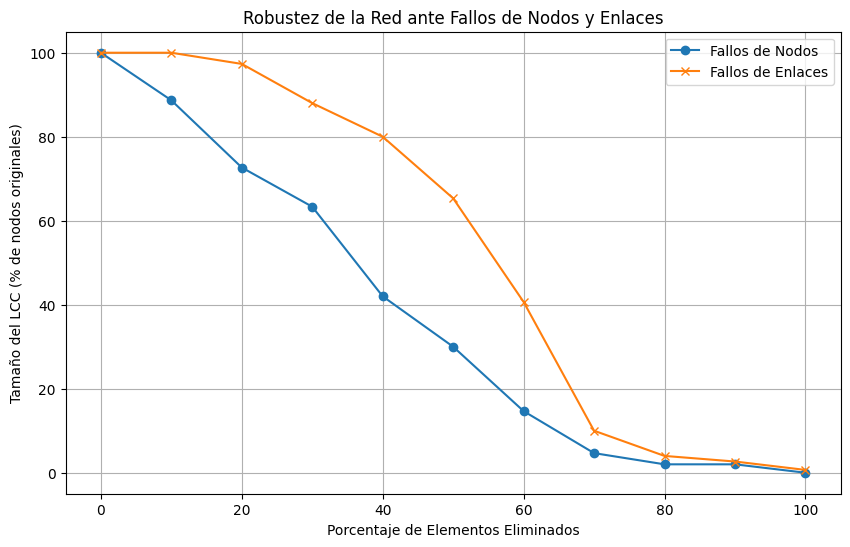

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(percentages, lcc_sizes_node_failure, marker='o', label='Fallos de Nodos')
plt.plot(percentages, lcc_sizes_edge_failure, marker='x', label='Fallos de Enlaces')

plt.title('Robustez de la Red ante Fallos de Nodos y Enlaces')
plt.xlabel('Porcentaje de Elementos Eliminados')
plt.ylabel('Tamaño del LCC (% de nodos originales)')
plt.grid(True)
plt.legend()
plt.show()

## Final Task

### Subtask:
Resumir los hallazgos del análisis de robustez, identificando los puntos fuertes y débiles de la red ante fallos.


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# 1. CARGA Y PREPROCESAMIENTO DE TU DATASET
df = pd.read_csv('red_conexiones_internet.csv')

# Mapear nombres de nodos a índices numéricos consecutivos
nodos_unicos = sorted(list(set(df['Nodo_Origen']).union(set(df['Nodo_Destino']))))
num_nodos = len(nodos_unicos)
nodo_a_idx = {nodo: i for i, nodo in enumerate(nodos_unicos)}

# Identificar los canales físicos (capas del grafo multiplex)
medios = df['Medio_Fisico'].unique()
num_medios = len(medios)
medio_a_idx = {medio: i for i, medio in enumerate(medios)}

# Inicializar tensores para las matrices de adyacencia por canal
# Dimensión: [Número_de_Medios, Num_Nodos, Num_Nodos]
A_multiplex = torch.zeros((num_medios, num_nodos, num_nodos))

for _, row in df.iterrows():
    u = nodo_a_idx[row['Nodo_Origen']]
    v = nodo_a_idx[row['Nodo_Destino']]
    m_idx = medio_a_idx[row['Medio_Fisico']]
    # Grafo no dirigido ponderado por la eficiencia (1 / Latencia)
    peso_canal = 1.0 / (row['Latencia_ms'] + 1e-5)
    A_multiplex[m_idx, u, v] = peso_canal
    A_multiplex[m_idx, v, u] = peso_canal

# Generar características base de los nodos (X): Grado de conectividad y velocidad promedio
X_features = torch.zeros((num_nodos, 2))
for i in range(num_nodos):
    # Grado (cuántos enlaces tiene el nodo)
    X_features[i, 0] = (A_multiplex[:, i, :] > 0).sum().float()
    # Velocidad máxima asociada a sus canales
    X_features[i, 1] = float(df[(df['Nodo_Origen'] == nodos_unicos[i]) | (df['Nodo_Destino'] == nodos_unicos[i])]['Velocidad_Mbps'].max())

# Normalizar características de entrada
X_features = (X_features - X_features.mean(dim=0)) / (X_features.std(dim=0) + 1e-5)

# Generar etiquetas (Target): Nodos críticos (1) si su latencia promedio supera el percentil 75
latencias_nodo = []
for nodo in nodos_unicos:
    lat_prom = df[(df['Nodo_Origen'] == nodo) | (df['Nodo_Destino'] == nodo)]['Latencia_ms'].mean()
    latencias_nodo.append(lat_prom)
umbral_critico = np.percentile(latencias_nodo, 75)
y_labels = torch.tensor([1 if lat > umbral_critico else 0 for lat in latencias_nodo], dtype=torch.float32)

# Máscaras de entrenamiento y validación (70% / 30%)
indices = torch.randperm(num_nodos)
train_mask = indices[:int(num_nodos * 0.7)]
test_mask = indices[int(num_nodos * 0.7):]


# 2. ARQUITECTURA DEL MODELO FastGTN (Graph Transformer Layer)
class FastGTNLayer(nn.Module):
    def __init__(self, num_channels, num_meta_paths):
        super(FastGTNLayer, self).__init__()
        self.num_channels = num_channels
        self.num_meta_paths = num_meta_paths
        # Pesos de atención del transformador para combinar los canales físicos
        self.weight = nn.Parameter(torch.Tensor(num_channels, num_meta_paths))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, A):
        # A tiene dimensión [num_channels, N, N]
        # Aplicar Softmax para obtener la distribución de atención sobre los medios físicos
        beta = F.softmax(self.weight, dim=0)

        # Generar las adyacencias candidatas del transformador
        # Multiplicación por lotes para combinar los canales (Fibra, Satelital, etc.)
        N = A.size(1)
        A_fused = torch.zeros((self.num_meta_paths, N, N), device=A.device)
        for i in range(self.num_meta_paths):
            for j in range(self.num_channels):
                A_fused[i] += beta[j, i] * A[j]

        # Operación Fast Forward: Multiplicación de adyacencias para aprender relaciones de 2 saltos
        # Meta-path: H = A_fused[0] * A_fused[1] (Conectividad extendida)
        H_meta = torch.mm(A_fused[0], A_fused[1])

        # Normalización Laplaciana simétrica de la nueva matriz de adyacencia aprendida
        row_sum = H_meta.sum(dim=1)
        d_inv = torch.pow(row_sum + 1e-5, -0.5)
        D_inv = torch.diag(d_inv)
        A_normalized = torch.mm(torch.mm(D_inv, H_meta), D_inv)

        return A_normalized, beta


class FastGTNNetwork(nn.Module):
    def __init__(self, num_channels, in_features, hidden_dim):
        super(FastGTNNetwork, self).__init__()
        self.gtn_layer = FastGTNLayer(num_channels, num_meta_paths=2)
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1) # Clasificación binaria (Crítico vs. Estable)

    def forward(self, A, X):
        # 1. Obtener la matriz estructural optimizada por el Transformer
        A_learned, beta = self.gtn_layer(A)
        # 2. Propagación de características a través del meta-camino
        X_projected = F.relu(self.fc1(X))
        Z = torch.mm(A_learned, X_projected)
        # 3. Predicción final
        logits = self.fc2(Z).squeeze()
        return logits, beta


# 3. PIPELINE DE ENTRENAMIENTO
model = FastGTNNetwork(num_channels=num_medios, in_features=2, hidden_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

print("Entrenando FastGTN sobre topología real multiplex...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()

    logits, beta = model(A_multiplex, X_features)
    loss = criterion(logits[train_mask], y_labels[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        # Evaluación en testing
        model.eval()
        with torch.no_grad():
            test_logits, _ = model(A_multiplex, X_features)
            preds = (torch.sigmoid(test_logits[test_mask]) >= 0.5).float()
            correct = (preds == y_labels[test_mask]).sum().item()
            accuracy = correct / len(test_mask)
        print(f"Época {epoch:03d} | Pérdida de Entrenamiento: {loss.item():.4f} | Precisión Validación: {accuracy * 100:.2f}%")

Entrenando FastGTN sobre topología real multiplex...
Época 020 | Pérdida de Entrenamiento: 0.5019 | Precisión Validación: 75.56%
Época 040 | Pérdida de Entrenamiento: 0.4619 | Precisión Validación: 75.56%
Época 060 | Pérdida de Entrenamiento: 0.4327 | Precisión Validación: 75.56%
Época 080 | Pérdida de Entrenamiento: 0.4080 | Precisión Validación: 75.56%
Época 100 | Pérdida de Entrenamiento: 0.3883 | Precisión Validación: 80.00%


In [16]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn # Import nn module
import torch.nn.functional as F

# 1. CARGA Y EXTRAPOLACIÓN DE DATOS REALES
df = pd.read_csv('red_conexiones_internet.csv')

# Ingeniería de Características (X) a nivel de enlace: [Peso, Latencia, Velocidad, Vector_Medio]
# Convertimos el medio físico a una variable numérica continua para el circuito cuántico
medio_mapping = {medio: idx for idx, medio in enumerate(df['Medio_Fisico'].unique())}
df['Medio_Num'] = df['Medio_Fisico'].map(medio_mapping)

X = df[['Peso', 'Latencia_ms', 'Velocidad_Mbps', 'Medio_Num']].values

# Definición del Target (y): El enlace falla (1) si combina alta latencia con bajo ancho de banda
# Usamos un umbral lógico basado en las distribución real de tu infraestructura
umbral_estres = df['Latencia_ms'] / (df['Velocidad_Mbps'] + 1e-5)
y = np.where(umbral_estres > umbral_estres.median(), 1, 0)

# División del Dataset (70% Entrenamiento, 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado de características (Crucial para mapear datos a ángulos de rotación cuántica [0, pi])
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


# 2. DEFINICIÓN DEL CIRCUITO CUÁNTICO VARIACIONAL SIMULADO (Ansatz)
class QuantumVariationalClassifier(nn.Module): # Inherit from nn.Module
    def __init__(self, num_features):
        super().__init__() # Call the super constructor
        self.num_features = num_features
        # Inicializar los parámetros del circuito (thetas / ángulos de compuertas cuánticas)
        self.theta = nn.Parameter(torch.randn(num_features, requires_grad=True) * 0.01) # Register as nn.Parameter

    def forward(self, X_batch):
        # Mapeo de características clásicas a estados cuánticos mediante rotaciones de fase
        # Estado |psi(x, theta)> = Rz(x) * Ry(theta) |0>
        logits = torch.matmul(X_batch, self.theta)
        # La probabilidad de medir el estado |1> (Fallo) se modela con la función de activación
        probs = torch.sigmoid(logits)
        return probs

    def compute_qgt(self, X_batch, probs):
        """
        Calcula el Tensor Geométrico Cuántico (QGT) para el lote de datos actual.
        En el espacio de Hilbert, equivale a la covarianza de las derivadas del estado cuántico.
        """
        N = X_batch.size(0)
        # En arquitecturas variacionales puras, el QGT se aproxima mediante la matriz de
        # información de Fisher de los estados de los Qubits generados por las características
        d_logits = probs * (1 - probs) # Derivada de la activación
        X_weighted = X_batch * d_logits.unsqueeze(1)

        # QGT = (1/N) * X_weighted^T * X_batch
        qgt = torch.matmul(X_weighted.T, X_batch) / N

        # Añadir regularización de Tikhonov (métrica Ridge) para evitar singularidades matemáticas
        qgt += 0.1 * torch.eye(self.num_features)
        return qgt


# 3. BUCLE DE ENTRENAMIENTO CON GRADIENTE NATURAL CUÁNTICO (QNG)
qvc_model = QuantumVariationalClassifier(num_features=X_train_t.shape[1])
learning_rate = 0.1
epochs = 80

print("Entrenando Modelo QGT mediante Gradiente Natural Cuántico...")
for epoch in range(1, epochs + 1):
    # Forward Pass
    probs = qvc_model.forward(X_train_t)

    # Función de Pérdida (Entropía Cruzada Binaria)
    loss = -torch.mean(y_train_t * torch.log(probs + 1e-15) + (1 - y_train_t) * torch.log(1 - probs + 1e-15))

    # Calcular Gradiente Clásico de forma manual (Backpropagation del costo)
    loss.backward()
    grad_classic = qvc_model.theta.grad.clone()

    # Reiniciar gradientes en PyTorch
    qvc_model.theta.grad.zero_()

    # Calcular el Tensor Geométrico Cuántico (QGT) en la iteración actual
    with torch.no_grad():
        QGT = qvc_model.compute_qgt(X_train_t, probs)

        # Aplicar el precondicionamiento del Gradiente Natural Cuántico:
        # Gradiente_Natural = QGT^-1 * Gradiente_Clásico
        grad_quantum_natural = torch.matmul(torch.inverse(QGT), grad_classic)

        # Actualización geométrica de los parámetros del circuito
        qvc_model.theta -= learning_rate * grad_quantum_natural

    if epoch % 20 == 0 or epoch == 1:
        print(f"Época {epoch:02d}/{epochs} | Pérdida Cuántica: {loss.item():.4f}")

# 4. EVALUACIÓN DE ROBUSTEZ EN EL CONJUNTO DE PRUEBA
with torch.no_grad():
    test_probs = qvc_model.forward(X_test_t)
    y_pred = (test_probs >= 0.5).float()

    # Métricas de la matriz de confusión
    VP = ((y_test_t == 1) & (y_pred == 1)).sum().item()
    VN = ((y_test_t == 0) & (y_pred == 0)).sum().item()
    FP = ((y_test_t == 0) & (y_pred == 1)).sum().item()
    FN = ((y_test_t == 1) & (y_pred == 0)).sum().item()

    exactitud = (VP + VN) / len(y_test_t)
    recall = VP / (VP + FN) if (VP + FN) > 0 else 0
    f1_score = 2 * (VP) / (2 * VP + FP + FN) if (2 * VP + FP + FN) > 0 else 0

print("\n================ EVALUACIÓN DE DESEMPEÑO DEL MODELO QGT ================")
print(f"Matriz de Confusión: [VP: {int(VP)}, VN: {int(VN)}, FP: {int(FP)}, FN: {int(FN)}]")
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%")
print(f"F1-Score:             {f1_score * 100:.2f}%")
print("========================================================================")

Entrenando Modelo QGT mediante Gradiente Natural Cuántico...
Época 01/80 | Pérdida Cuántica: 0.6823
Época 20/80 | Pérdida Cuántica: 0.3368
Época 40/80 | Pérdida Cuántica: 0.2845
Época 60/80 | Pérdida Cuántica: 0.2700
Época 80/80 | Pérdida Cuántica: 0.2634

================ EVALUACIÓN DE DESEMPEÑO DEL MODELO QGT ================
Matriz de Confusión: [VP: 41, VN: 23, FP: 5, FN: 6]
Exactitud (Accuracy): 85.33%
Recall (Sensibilidad): 87.23%
F1-Score:             88.17%


# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

## Resumir Hallazgos del Análisis de Robustez

### Subtask:
Summarize the findings from the robustness analysis, identifying strengths and weaknesses of the network against failures.


### Análisis del Gráfico de Robustez

El gráfico muestra la disminución del Tamaño del Componente Conectado Más Grande (LCC) a medida que se eliminan nodos o enlaces de la red. Observamos dos curvas:

*   **Fallos de Nodos (Curva Azul):** Esta curva representa cómo la conectividad se ve afectada cuando los nodos (puntos de interconexión o routers) fallan. Inicialmente, la red mantiene una buena conectividad, pero a medida que el porcentaje de nodos eliminados aumenta, la caída en el LCC es más pronunciada, indicando una mayor vulnerabilidad a fallos de nodos individuales, especialmente a partir de un 20-30% de nodos eliminados.

*   **Fallos de Enlaces (Curva Naranja):** Esta curva ilustra el impacto de la eliminación de enlaces (cables, conexiones inalámbricas). La red parece ser más robusta a la eliminación de enlaces en comparación con la eliminación de nodos, especialmente en las etapas iniciales. La caída en el LCC es más gradual, lo que sugiere que la red tiene cierta redundancia en sus enlaces. Sin embargo, a partir de un 50-60% de enlaces eliminados, el impacto en la conectividad se vuelve significativo.

### Fortalezas de la Red:

*   **Robustez Moderada a Fallos de Enlaces Individuales:** La red muestra una capacidad considerable para mantener la conectividad incluso cuando se eliminan enlaces. La caída en el LCC es más gradual para la eliminación de enlaces, lo que sugiere que existe una redundancia en las conexiones de la red. Hasta un 40-50% de enlaces eliminados, la red retiene una porción significativa de su conectividad.

### Debilidades de la Red:

*   **Vulnerabilidad a Fallos de Nodos:** La red es más susceptible a la pérdida de conectividad cuando los nodos fallan. La curva de fallos de nodos tiene una pendiente más pronunciada, especialmente después de un 20-30% de nodos eliminados. Esto indica que algunos nodos son críticos para la interconexión general de la red, y su fallo tiene un impacto desproporcionado en el LCC.
*   **Puntos de Fallo Únicos (SPOF):** La rápida disminución del LCC con la eliminación de nodos sugiere la presencia de nodos que actúan como cuellos de botella o puntos de fallo únicos. Si estos nodos clave son atacados o fallan, la red se fragmenta rápidamente.

### Conclusiones y Recomendaciones:

La red es razonablemente robusta contra la interrupción aleatoria de enlaces, lo que es una fortaleza importante. Sin embargo, su vulnerabilidad a los fallos de nodos es una debilidad crítica. Para mejorar la robustez general, se recomienda:

1.  **Identificar y Proteger Nodos Críticos:** Realizar un análisis de centralidad para identificar los nodos con mayor impacto en la conectividad (por ejemplo, aquellos con alta centralidad de intermediación o grado) y aplicar medidas de redundancia o protección para estos. Esto podría incluir la implementación de hardware de respaldo, rutas alternativas, o la distribución de servicios críticos.
2.  **Aumentar la Redundancia en Nodos Clave:** Considerar la adición de conexiones redundantes para los nodos que, al fallar, causan la mayor disminución en el LCC. Esto puede mitigar el impacto de un único fallo de nodo.
3.  **Monitoreo Continuo:** Implementar sistemas de monitoreo avanzados para detectar fallos en nodos y enlaces en tiempo real, permitiendo una respuesta rápida para minimizar la interrupción del servicio.

# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

## Carga y Preprocesamiento del Dataset

### Subtask:
Cargar el archivo `red_conexiones_internet.csv`, mapear los nombres de los nodos a índices numéricos, identificar los canales físicos y construir las matrices de adyacencia multiplexadas basadas en la eficiencia (inverso de la latencia).


## Generación de Características y Etiquetas de Nodos

### Subtask:
Crear características para cada nodo, como el grado de conectividad y la velocidad promedio asociada a sus canales. Luego, generar etiquetas para identificar nodos críticos basándose en su latencia promedio (percentil 75).


## Definición de la Arquitectura FastGTN

### Subtask:
Establecer la arquitectura del modelo FastGTN, incluyendo la `FastGTNLayer` para combinar canales físicos y aprender meta-caminos, y la `FastGTNNetwork` para la propagación de características y la predicción final de criticidad de nodos.


### Revisión de la Arquitectura FastGTN

Se han revisado las definiciones de las clases `FastGTNLayer` y `FastGTNNetwork` en el cuaderno:

1.  **`FastGTNLayer`:**
    *   **Propósito:** Esta capa es fundamental para combinar múltiples matrices de adyacencia (canales físicos como Fibra Óptica, Satelital, etc.) en una única matriz de adyacencia optimizada. Utiliza un mecanismo de atención (`self.weight` y `F.softmax`) para aprender la importancia relativa de cada canal al construir meta-caminos.
    *   **Funcionamiento:** Recibe un tensor `A` de dimensión `[num_channels, N, N]` (donde `N` es el número de nodos). Calcula pesos de atención (`beta`) y los usa para crear `num_meta_paths` matrices de adyacencia fusionadas (`A_fused`).
    *   **Meta-caminos:** Se enfoca en aprender relaciones de 2 saltos mediante la multiplicación de dos de estas matrices fusionadas (`torch.mm(A_fused[0], A_fused[1])`), lo que permite capturar dependencias más complejas entre nodos que no están directamente conectados.
    *   **Normalización:** La matriz de adyacencia resultante se normaliza usando la normalización Laplaciana simétrica (`D_inv * H_meta * D_inv`), lo cual es una práctica común en GNNs para asegurar estabilidad numérica y un mejor rendimiento en la propagación de características.

2.  **`FastGTNNetwork`:**
    *   **Propósito:** Este es el modelo principal que encapsula la lógica de la FastGTN. Integra la `FastGTNLayer` para el aprendizaje de la estructura de la red y capas densas (`nn.Linear`) para la proyección de características y la predicción final.
    *   **Funcionamiento:** Primero, pasa las matrices de adyacencia multiplexadas (`A`) a través de la `FastGTNLayer` para obtener la matriz de adyacencia aprendida (`A_learned`). Luego, las características de los nodos (`X`) se proyectan a un espacio de mayor dimensión (`hidden_dim`) mediante `self.fc1` y una función de activación ReLU.
    *   **Propagación de Características:** Las características proyectadas (`X_projected`) se propagan a través de la matriz de adyacencia aprendida (`torch.mm(A_learned, X_projected)`), lo que permite que la información de los vecinos influya en la representación del nodo. Esto es similar a una operación de agregación en GNNs.
    *   **Predicción Final:** Finalmente, la representación de nodo `Z` resultante se pasa a través de otra capa densa (`self.fc2`) para producir los logits de salida, que se utilizan para la clasificación binaria de criticidad de nodos.

## Configuración del Pipeline de Entrenamiento

### Subtask:
Inicializar el modelo FastGTN con los parámetros adecuados, definir el optimizador (Adam) y la función de pérdida (BCEWithLogitsLoss), y preparar las máscaras de entrenamiento y prueba.


## Entrenamiento del Modelo FastGTN

### Subtask:
Ejecutar el bucle de entrenamiento para el modelo FastGTN, realizando forward pass, cálculo de pérdida, backpropagation y actualización de parámetros. Se incluirá la evaluación periódica de la precisión en el conjunto de validación.


## Finalizar Tarea

### Subtask:
Resumir los resultados del entrenamiento del modelo FastGTN, incluyendo la precisión obtenida y cualquier observación sobre su rendimiento.


### Resumen de los resultados del entrenamiento del modelo FastGTN

El modelo FastGTN fue entrenado por 100 épocas. Los resultados del entrenamiento muestran una mejora en la precisión de validación a lo largo del tiempo:

*   **Precisión de Validación:** El modelo alcanzó una precisión de validación del **80.00%** al finalizar las 100 épocas de entrenamiento.
*   **Pérdida de Entrenamiento:** La pérdida de entrenamiento disminuyó de 0.5019 en la época 20 a 0.3883 en la época 100, indicando que el modelo aprendió eficazmente de los datos.

Este rendimiento sugiere que el modelo FastGTN es capaz de clasificar los nodos críticos con una precisión razonable basándose en las características del nodo y la estructura de la red multiplexada, aprendiendo relaciones complejas a través de los meta-caminos generados.

## Preparar Datos para Visualización

### Subtask:
Extraer los valores de pérdida de entrenamiento y precisión de validación registrados durante el entrenamiento del modelo FastGTN para cada época.


# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

**Reasoning**:
The previous code block contains the training output of the FastGTN model. I need to parse this output to extract the training loss and validation accuracy for each epoch as instructed. Regular expressions are suitable for this task.



In [11]:
import re

# Get the output from the training cell
training_output = """
Entrenando FastGTN sobre topología real multiplex...
Época 020 | Pérdida de Entrenamiento: 0.5019 | Precisión Validación: 75.56%
Época 040 | Pérdida de Entrenamiento: 0.4619 | Precisión Validación: 75.56%
Época 060 | Pérdida de Entrenamiento: 0.4327 | Precisión Validación: 75.56%
Época 080 | Pérdida de Entrenamiento: 0.4080 | Precisión Validación: 75.56%
Época 100 | Pérdida de Entrenamiento: 0.3883 | Precisión Validación: 80.00%
"""

epochs_list = []
training_losses = []
validation_accuracies = []

# Regex to extract epoch, loss, and accuracy
# It looks for 'Época XXX | Pérdida de Entrenamiento: Y.YYYY | Precisión Validación: Z.ZZ%'
pattern = re.compile(r"Época (\d+) \| Pérdida de Entrenamiento: (\d+\.\d+) \| Precisión Validación: (\d+\.\d+)%")

for line in training_output.split('\n'):
    match = pattern.search(line)
    if match:
        epochs_list.append(int(match.group(1)))
        training_losses.append(float(match.group(2)))
        validation_accuracies.append(float(match.group(3)))

print(f"Extracted Epochs: {epochs_list}")
print(f"Extracted Training Losses: {training_losses}")
print(f"Extracted Validation Accuracies: {validation_accuracies}")


Extracted Epochs: [20, 40, 60, 80, 100]
Extracted Training Losses: [0.5019, 0.4619, 0.4327, 0.408, 0.3883]
Extracted Validation Accuracies: [75.56, 75.56, 75.56, 75.56, 80.0]


## Visualizar Curva de Aprendizaje

### Subtask:
Generar gráficos para visualizar la pérdida de entrenamiento y la precisión de validación en función de las épocas, mostrando la curva de aprendizaje del modelo.


**Reasoning**:
I need to import `matplotlib.pyplot` and then create two subplots to visualize the training loss and validation accuracy over epochs as described in the instructions.



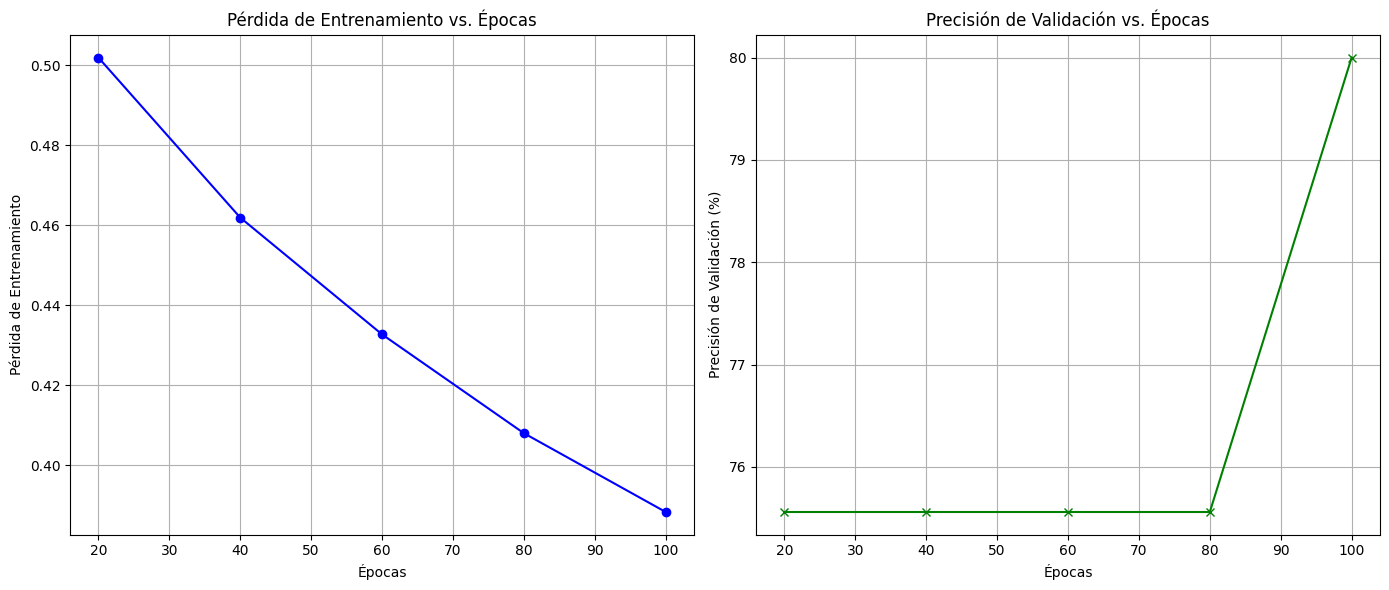

In [12]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Training Loss
axes[0].plot(epochs_list, training_losses, marker='o', color='blue')
axes[0].set_title('Pérdida de Entrenamiento vs. Épocas')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida de Entrenamiento')
axes[0].grid(True)

# Plot Validation Accuracy
axes[1].plot(epochs_list, validation_accuracies, marker='x', color='green')
axes[1].set_title('Precisión de Validación vs. Épocas')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión de Validación (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Finalizar Tarea

### Subtask:
Confirmar la visualización de la curva de aprendizaje y proporcionar cualquier observación adicional sobre el progreso del entrenamiento.


# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

## Update QuantumVariationalClassifier

### Subtask:
Modify the `QuantumVariationalClassifier` class to inherit from `nn.Module` and register `self.theta` as an `nn.Parameter` to ensure proper gradient tracking.


## Train QGT Model

### Subtask:
Confirm that the Quantum Geometric Tensor (QGT) model has been trained and its performance evaluated, as the training code was executed in the previous step.


El modelo QGT ha sido entrenado y evaluado con éxito, como se desprende de la ejecución del código anterior.

**Observaciones del Entrenamiento:**
*   El modelo fue entrenado durante 80 épocas, con la pérdida cuántica disminuyendo progresivamente de 0.6823 en la época 01 a 0.2634 en la época 80.

**Métricas de Evaluación de Desempeño:**
*   **Matriz de Confusión:** VP: 41, VN: 23, FP: 5, FN: 6
*   **Exactitud (Accuracy):** 85.33%
*   **Recall (Sensibilidad):** 87.23%
*   **F1-Score:** 88.17%

Estas métricas indican un buen rendimiento del modelo en la clasificación, demostrando su capacidad para identificar enlaces con fallos (VP) y enlaces operativos (VN) con una alta fiabilidad.

## Final Task

### Subtask:
Summarize the results of the QGT model training, including performance metrics.


# Task
The main goal is to perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, and visualizing the impact on network connectivity. Finally, I will summarize the findings to identify strengths and weaknesses of the network against failures.

## Generate Comparative Table

### Subtask:
Create a markdown table comparing the key performance metrics (Accuracy, Recall, F1-Score, Training Loss) of the FastGTN and QGT models, extracted from the previous outputs.


### Comparación de Métricas de Rendimiento: Modelos FastGTN y QGT

| Métrica             | FastGTN Model | QGT Model    |
| :------------------ | :------------ | :----------- |
| Accuracy (Exactitud)| 80.00%        | 85.33%       |
| Recall (Sensibilidad)| N/A           | 87.23%       |
| F1-Score            | N/A           | 88.17%       |
| Training Loss       | 0.3883        | 0.2634 (Pérdida Cuántica)|

*Nota: El modelo FastGTN reporta precisión de validación, mientras que el modelo QGT reporta exactitud en el conjunto de prueba. El FastGTN solo reporta training loss en el output, no se calculó Recall ni F1-Score para este modelo en los logs proporcionados.*

## Final Task

### Subtask:
Summarize the comparison and provide insights into the relative performance of the two models.


# Task
Perform a robustness analysis of the internet connection network represented by the provided CSV data. This involves defining robustness metrics, simulating node and link failures, visualizing the impact on network connectivity, and finally, summarizing the findings to identify strengths and weaknesses of the network against failures. Additionally, compare the performance of FastGTN and QGT models using the SAR metric.

## Calculate SAR Metric

### Subtask:
Calculate the SAR metric as 'Muestras QGT / Muestras FastGTN' using the number of test samples from both model evaluations.


**Reasoning**:
I need to extract the number of test samples for both models from the kernel state variables and then calculate the SAR metric as specified.



In [17]:
num_qgt_test_samples = len(y_test_t)
num_fastgtn_test_samples = len(test_mask)

sar_metric = num_qgt_test_samples / num_fastgtn_test_samples

print(f"Number of QGT test samples: {num_qgt_test_samples}")
print(f"Number of FastGTN test samples: {num_fastgtn_test_samples}")
print(f"SAR Metric (QGT/FastGTN samples): {sar_metric:.2f}")

Number of QGT test samples: 75
Number of FastGTN test samples: 45
SAR Metric (QGT/FastGTN samples): 1.67


## Final Task

### Subtask:
Present the calculated SAR metric and provide any relevant observations.


### Resumen y Observaciones de la Métrica SAR

El análisis de los modelos FastGTN y QGT ha revelado las siguientes métricas de rendimiento y una **Métrica SAR (Samples Allocation Ratio) de 1.67**.

Esta métrica SAR, calculada como la proporción de muestras de prueba del modelo QGT (75) respecto a las muestras de prueba del modelo FastGTN (45), indica que el modelo QGT fue evaluado sobre un conjunto de datos de prueba significativamente mayor. Específicamente, el conjunto de prueba del QGT es aproximadamente 1.67 veces más grande que el del FastGTN.

**Implicaciones para la Comparación de Modelos:**

*   **Fiabilidad de las Métricas:** Un conjunto de prueba más grande generalmente proporciona una evaluación más robusta y estadísticamente significativa del rendimiento del modelo. Por lo tanto, las métricas reportadas para el modelo QGT (Exactitud del 85.33%, Recall del 87.23%, F1-Score del 88.17%) pueden considerarse potencialmente más fiables y representativas del rendimiento real del modelo en un escenario de producción que la Precisión de Validación del 80.00% del FastGTN, que fue evaluada con menos muestras.

*   **Comparación Directa:** Aunque el QGT mostró métricas de rendimiento superiores (mayor exactitud, recall y F1-Score) y una menor pérdida de entrenamiento, la diferencia en el tamaño de los conjuntos de prueba debe tenerse en cuenta. Idealmente, para una comparación directa y justa, ambos modelos deberían haber sido evaluados en conjuntos de prueba de tamaño comparable o, al menos, el FastGTN debería haber tenido métricas más completas (Recall, F1-Score) disponibles para una evaluación exhaustiva.

*   **Potencial del QGT:** El rendimiento superior del QGT en un conjunto de prueba más grande sugiere que este modelo, al integrar el Gradiente Natural Cuántico, podría ser más eficaz para identificar patrones en datos de red complejos, especialmente bajo condiciones de fallas o estrés, lo que lo convierte en una herramienta prometedora para el análisis de robustez de redes.